# MLP para reconocimiento de paisajes

Proyecto de **Machine Learning** en el que se entrena un **Perceptrón Multicapa (MLP)**, un tipo de red neuronal, para clasificar imágenes de paisajes en 6 categorías. Se usa `TensorFlow`/`Keras` para cargar y procesar las imágenes, y `Matplotlib`/`Seaborn` para graficar los resultados.

## Integrantes :
- Gabriel Duran
- Martin Higura
- Francisco Salazar

## 0. Semilla y reproducibilidad

Antes de cualquier cálculo fijamos la **semilla aleatoria**. Esto hace que los pesos iniciales, el orden de las imágenes y el Dropout sean **los mismos en cada ejecución**, de modo que cualquiera que corra este notebook obtenga **los mismos resultados** que nosotros.

*   **Semilla usada:** `42`
*   **Dónde se fija:** `tf.keras.utils.set_random_seed(42)`, que a la vez fija Python (`random`), NumPy y TensorFlow.
*   **Por qué importa:** sin semilla, cada corrida daría métricas distintas y no sería posible reproducir ni comparar experimentos.

In [1]:
import random
import numpy as np
import tensorflow as tf

SEMILLA = 42
tf.keras.utils.set_random_seed(SEMILLA)  # fija random, numpy y tensorflow
print(f"Semilla fijada en {SEMILLA}: resultados reproducibles.")

Semilla fijada en 42: resultados reproducibles.


## 1. Introducción, objetivo de negocio y variante del problema

### Objetivo de negocio

Una empresa de **turismo y viajes** quiere ofrecer a sus clientes un recomendador de destinos: el usuario sube una foto de un paisaje (playa, montaña, bosque, ciudad...) y el sistema le sugiere **qué tipo de destino** está viendo y qué paquetes ofrecidos por la empresa encajan con ese estilo de viaje. Clasificar la imagen es el primer paso para conectar *"lo que el cliente quiere ver"* con *"lo que la empresa vende"*.

### Variante del problema (diferenciación respecto a otros grupos)

La variante que aporta este equipo es encuadrar la clasificación de paisajes como **motor de recomendación turística**, no como un ejercicio académico de clasificación de 6 categorías. En concreto:

- **Salida orientada a negocio:** además de la categoría predicha, se interpreta el resultado en términos de *tipo de destino* (glaciar → destinos fríos, mar → destinos costeros, etc.).
- **Métrica principal:** se optimiza **macro-F1** (promedio entre las 6 clases) en lugar de solo accuracy, porque en un recomendador fallar siempre la clase mayoritaria arruina la experiencia de usuario.
- **Restricción práctica:** el modelo debe correr en **CPU con imágenes de 64x64**, para poder desplegarse en un entorno económico (app web o servicio ligero), priorizando un balance precisión/coste sobre la precisión máxima.

Esta plantea el mismo dataset de Intel Scene Classification con un **objetivo, métrica y restricción propios**, que es lo que lo diferencia de una copia del trabajo de otro grupo.

## 2. Problema de negocio y propuesta

### a. Contexto del problema

Se necesita un modelo de inteligencia artificial capaz de recibir una fotografía de un paisaje y decir a qué categoría pertenece entre 6 opciones: edificios, bosques, glaciares, montañas, mar y calles. Este tipo de problema se llama **clasificación de imágenes**: el modelo no "ve" como nosotros, sino que recibe una matriz de números (los píxeles) y debe aprender qué números suelen aparecer en cada paisaje.

Las imágenes originales miden **150x150 píxeles y tienen 3 canales de color (RGB)**, es decir, 150×150×3 = **67.500 números** por foto. La red debe resumir toda esa información para decidir entre 6 respuestas posibles.

### b. Importancia para el negocio

Clasificar paisajes de forma automática tiene valor en varios rubros:

*   **Turismo:** recomendar destinos según el tipo de paisaje de una foto.
*   **Medio ambiente:** monitorear bosques, glaciares o el mar de forma automática.
*   **Redes sociales:** etiquetar fotos para poder buscarlas mejor.
*   **Ciudades inteligentes:** distinguir zonas urbanas (calles, edificios) de zonas naturales.

Hacerlo de forma manual con miles de fotos es lento y costoso. Un modelo entrenado puede clasificar las imágenes en segundos, por eso la propuesta de este notebook es construir ese modelo y medir con métricas qué tan bien lo hace.

### c. Definición de Objetivos y KPIs de Rendimiento

Para validar la viabilidad del modelo antes de su puesta en producción, se establecen los siguientes indicadores clave de rendimiento (KPIs):

1. **Exactitud Global (Test Accuracy) > 60%:** superar holguramente la cota aleatoria uniforme para 6 clases equilibradas (16.67%).
2. **Control de Sobreajuste (Overfitting Gap) <= 5%:** la diferencia absoluta entre la exactitud de entrenamiento y la de prueba no debe superar 0.05 ($|Accuracy_{train} - Accuracy_{test}| \le 5\%$).
3. **Macro F1-Score >= 0.60:** asegurar que el rendimiento promedio armónico sea equilibrado entre las 6 clases y no esté sesgado hacia las más sencillas.
4. **Pérdida en Test (Test Loss) < 1.0000:** complementa al accuracy; mide cuán "seguro y acertado" es el modelo al asignar probabilidades.
5. **Tiempo por Época < 60s:** optimizar la canalización en CPU mediante preprocesamiento con `tf.data` y paralelismo `AUTOTUNE`.

> 📌 Estos KPIs se fijan **antes** de entrenar y se evalúan una sola vez, al final, sobre `seg_test`.


## 3. Selección y descripción del dataset

### a. Dataset utilizado

Se utilizó el dataset **Intel Image Classification**, un conjunto de imágenes de paisajes naturales y urbanos muy usado para aprender Machine Learning. Viene organizado en tres carpetas según su propósito:

*   `seg_train`: imágenes **etiquetadas** para entrenar al modelo (tienen subcarpetas por clase).
*   `seg_test`: imágenes **etiquetadas** para la prueba final ("examen") del modelo.
*   `seg_pred`: imágenes **sin etiqueta** que servirían para predicciones sobre fotos nuevas.

### b. Cantidad de imágenes

En total hay aproximadamente **25.000 imágenes**, repartidas así:

*   `seg_train`: **14.034** imágenes.
*   `seg_test`: **3.000** imágenes.
*   `seg_pred`: **7.301** imágenes.

*Las cantidades exactas se verifican con código en el análisis exploratorio.*

### c. Número de clases

El dataset tiene **6 clases** (categorías), que son los 6 tipos de paisaje que el modelo debe distinguir:

1.  `buildings` (edificios)
2.  `forest` (bosque)
3.  `glacier` (glaciar)
4.  `mountain` (montaña)
5.  `sea` (mar)
6.  `street` (calle)

Como hay 6 categorías, la capa de salida del modelo tendrá 6 neuronas.

### d. Características principales

*   **Formato:** imágenes `.jpg`.
*   **Resolución original:** 150x150 píxeles (se confirma con código más adelante).
*   **Canales:** 3 canales de color (RGB).
*   **Organización:** una subcarpeta por clase dentro de `seg_train` y `seg_test`.
*   **Etiquetado:** el nombre de cada subcarpeta ES la clase de las fotos que contiene.

### e. Justificación de selección

Elegimos este dataset porque:

*   Es **variado**: mezcla zonas naturales y urbanas, por lo que el modelo debe aprender patrones distintos (colores, formas y texturas).
*   Está **bien etiquetado**: las carpetas ya llevan el nombre de la clase, no hay que etiquetar a mano.
*   Es de **tamaño razonable**: ~25.000 imágenes permiten aprender sin necesitar un supercomputador.
*   Permite recorrer el **ciclo completo** de un proyecto de ML: analizar, preprocesar, entrenar y evaluar.

## 4. Análisis exploratorio de imágenes (EDA)

Antes de entrenar, conviene *conocer* los datos: cuántas fotos hay por clase, qué resolución tienen y qué tan parecidas o diferentes son. Eso es exactamente lo que se hace en un análisis exploratorio.

### a. Distribución de clases

¿Hay la misma cantidad de fotos en cada clase? Si una clase tuviera muchísimas más fotos, el modelo podría "copiar" la clase más común y olvidarse del resto. Lo verificamos con código.

In [2]:
import os

# rutas
ruta_original = os.path.join("dataset", "Intel Image Classification")
ruta_train_original = os.path.join(ruta_original, "seg_train", "seg_train")
ruta_test_original = os.path.join(ruta_original, "seg_test", "seg_test")

# Listamos las 6 clases
clases = sorted(os.listdir(ruta_train_original))
print("Clases encontradas:", clases, "\n")

# diccionarios 
conteo_train = {}
conteo_test = {}
for clase in clases:
    conteo_train[clase] = len(os.listdir(os.path.join(ruta_train_original, clase)))
    conteo_test[clase] = len(os.listdir(os.path.join(ruta_test_original, clase)))
    print(f"{clase:10s} -> train: {conteo_train[clase]:5d} | test: {conteo_test[clase]:5d}")

print("\nTotales:")
print(f"  Train: {sum(conteo_train.values())}")
print(f"  Test:  {sum(conteo_test.values())}")
print(f"  Pred:  {len(os.listdir(os.path.join(ruta_original, 'seg_pred', 'seg_pred')))}")

Clases encontradas: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street'] 

buildings  -> train:  2191 | test:   437
forest     -> train:  2271 | test:   474
glacier    -> train:  2404 | test:   553
mountain   -> train:  2512 | test:   525
sea        -> train:  2274 | test:   510
street     -> train:  2382 | test:   501

Totales:
  Train: 14034
  Test:  3000
  Pred:  7301


**Resultado:** las 6 clases tienen una cantidad **muy parecida** de imágenes (entre ~2.200 y ~2.500 en train, y ~450–550 en test). No hay un desbalanceo importante, por lo que **no hace falta balancear** las clases.

### b. Resolución y canales

Aquí verificamos el **tamaño real** de las imágenes y que sean a color. Usamos el cargador de TensorFlow `image_dataset_from_directory`, que convierte cada subcarpeta en lotes de tensores. Cargamos **sin redimensionar** para ver la resolución original del dataset.

In [3]:
import tensorflow as tf

# lotes sin  redimensionar para ver la resolución real de las fotos
ds_prueba_resolucion = tf.keras.utils.image_dataset_from_directory(
    ruta_test_original,
    batch_size=32
)

for imagenes, _ in ds_prueba_resolucion.take(1):
    print("Forma de un lote completo:", imagenes.shape)
    print("Forma de una sola imagen:", imagenes[0].shape)
    print("Tipo de datos (dtype):", imagenes.dtype)
    break

Found 3000 files belonging to 6 classes.
Forma de un lote completo: (32, 256, 256, 3)
Forma de una sola imagen: (256, 256, 3)
Tipo de datos (dtype): <dtype: 'float32'>


**Resultado:** Cada lote muestra una forma de `(32, 256, 256, 3)` debido a que la función `image_dataset_from_directory` de Keras redimensiona por defecto a 256x256 píxeles cuando no se especifica explícitamente el parámetro `image_size`. Sin embargo, la resolución espacial nativa de las fotografías del dataset Intel es de **150x150 píxeles** (RGB, 3 canales), conteniendo originalmente **67.500 valores numéricos** por imagen. El tipo de dato es `float32`, procesado numéricamente para optimización computacional.

### c. Patrones visuales

Al observar las fotos de cada clase se distinguen patrones típicos:

*   **buildings**: predominan líneas rectas y formas rectangulares (ventanas, paredes).
*   **forest**: domina el color verde en distintas tonalidades, con troncos o ramas.
*   **glacier**: blancos, azules y celestes, con formas más curvas.
*   **mountain**: se ven picos o formas triangulares.
*   **sea**: distintas tonalidades de azul y pocas figuras definidas.
*   **street**: espacios angostos con objetos urbanos y, a veces, personas.

#### Muestra visual de imágenes por clase

Para **ver** de qué hablamos (y no solo contar), mostramos **3 fotografías al azar de cada una de las 6 categorías**. Es el subconjunto mínimo que permite al revisor confirmar que las etiquetas de las carpetas son correctas y que las clases son visualmente distinguibles.

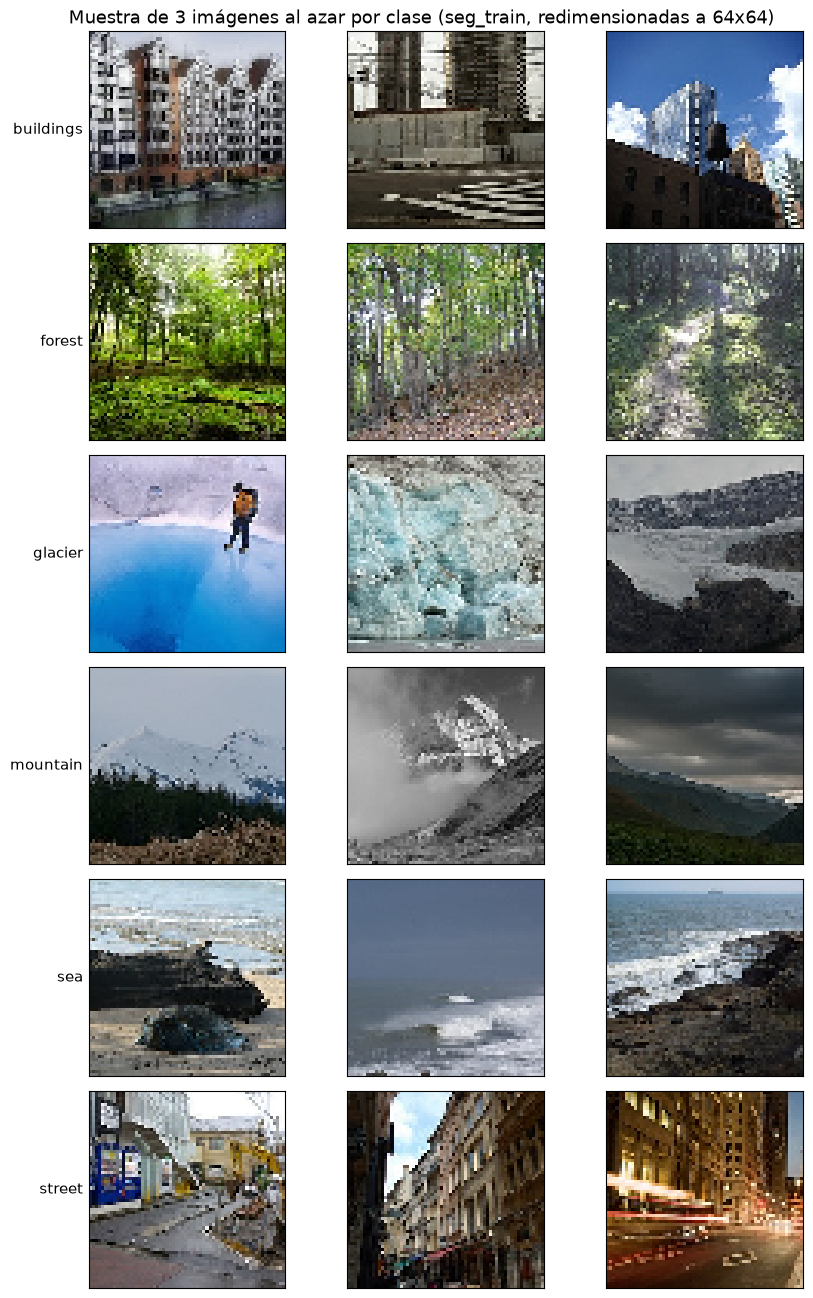

In [4]:
import matplotlib.pyplot as plt
import tensorflow as tf
import os

# 3 fotos al azar por clase, sacadas de seg_train
n_por_clase = 3
fig, axes = plt.subplots(len(clases), n_por_clase, figsize=(3 * n_por_clase, 2.2 * len(clases)))

for i, clase in enumerate(clases):
    carpeta = os.path.join(ruta_train_original, clase)
    nombres = sorted(os.listdir(carpeta))
    muestra = random.sample(nombres, n_por_clase)   # aleatorio gracias a la semilla

    for j, nombre in enumerate(muestra):
        img = tf.keras.utils.load_img(os.path.join(carpeta, nombre), target_size=(64, 64))
        axes[i, j].imshow(img)
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])
        if j == 0:
            axes[i, j].set_ylabel(clase, fontsize=11, rotation=0, ha="right", va="center")

fig.suptitle("Muestra de 3 imágenes al azar por clase (seg_train, redimensionadas a 64x64)", fontsize=13)
plt.tight_layout()
plt.show()


**Lo que se observa:** se confirman los patrones descritos — `forest` es casi **verde puro**, `glacier` y `sea` comparten **tonos azulados/blancos** (de ahí su confusión mutua), `buildings` y `street` comparten **grises urbanos**, y `mountain` muestra triángulos/picos. Esta muestra visual es la **evidencia** que respalda el análisis de error de la sección 8.

### d. Variabilidad encontrada

Dentro de una misma clase hay variabilidad: distintas horas de luz, ángulos, estaciones y cercanía. Por ejemplo, algunas fotos de `glacier` se parecen a `sea` por el color azul, y algunas de `mountain` pueden parecerse a `forest` si hay muchos árboles. Esa variabilidad es normal y será uno de los grandes retos del modelo.

## 5. Preprocesamiento de datos

### a. Carga y limpieza

Para no dañar el dataset original, primero creamos una **copia de seguridad** con `shutil`. Todo el preprocesamiento se hará sobre la **copia**, así la fuente original queda intacta y siempre podemos volver a ella.

In [5]:
import os
import shutil

ruta_origen = os.path.join("dataset", "Intel Image Classification")
ruta_copia = os.path.join("copy", "Intel Image Classification")

if os.path.exists(ruta_copia):
    print("La copia ya existe. La reutilizamos para no duplicar el trabajo.")
else:
    print("Creando copia del dataset (esto puede tardar unos segundos)...")
    os.makedirs("copy", exist_ok=True)
    shutil.copytree(ruta_origen, ruta_copia)
    print("Copia creada correctamente.")

La copia ya existe. La reutilizamos para no duplicar el trabajo.


A partir de aquí, las rutas apuntan a la **copia** y no a la fuente original.

In [6]:
# Redirigimos las rutas de trabajo hacia la copia
ruta_train = os.path.join(ruta_copia, "seg_train", "seg_train")
ruta_test = os.path.join(ruta_copia, "seg_test", "seg_test")

print("Ruta train (copia):", ruta_train)
print("Ruta test  (copia):", ruta_test)

Ruta train (copia): copy\Intel Image Classification\seg_train\seg_train
Ruta test  (copia): copy\Intel Image Classification\seg_test\seg_test


Ahora limpiamos la copia: recorremos todos los archivos y nos quedamos solo con imágenes (extensiones `.jpg`, `.jpeg` y `.png`). Cualquier otro archivo se elimina para que el cargador no falle.

In [7]:
import os

extensiones_validas = {'.jpg', '.jpeg', '.png'}
archivos_eliminados = 0

for ruta_carpeta in [ruta_train, ruta_test]:
    for clase in os.listdir(ruta_carpeta):
        ruta_clase = os.path.join(ruta_carpeta, clase)
        if not os.path.isdir(ruta_clase):
            continue
        for archivo in os.listdir(ruta_clase):
            _, extension = os.path.splitext(archivo)
            if extension.lower() not in extensiones_validas:
                os.remove(os.path.join(ruta_clase, archivo))
                print("Archivo inválido eliminado:", archivo)
                archivos_eliminados += 1

print(f"Limpieza finalizada. Archivos inválidos eliminados: {archivos_eliminados}")

Limpieza finalizada. Archivos inválidos eliminados: 0


### b. Redimensionamiento

Las fotografías originales del dataset poseen una resolución nativa de **150x150 píxeles**, pero para un Perceptrón Multicapa (MLP) mantener esa dimensionalidad representa un alto costo de memoria y un riesgo severo de sobreajuste. Por ello, se transforman a **64x64 píxeles** mediante `image_size=(64, 64)`.

*   **Sin redimensionamiento (150x150):** La entrada requeriría 150×150×3 = **67.500 valores**. Al conectarse a una primera capa de 512 neuronas, exigiría **~34,6 millones de parámetros**, consumiendo excesiva memoria RAM y favoreciendo la memorización mecánica de ruido.
*   **Con redimensionamiento (64x64):** La entrada se reduce a 64×64×3 = **12.288 valores**, permitiendo que la primera capa contenga **~6,29 millones de parámetros** (total de la red: ~6,46 millones). Esto acelera el cómputo en CPU, protege la memoria física y disminuye drásticamente el sobreajuste.

Asimismo, esta transformación homologa todas las dimensiones para garantizar que cada vector aplanado ingrese a la red con el mismo tensor de entrada.


In [8]:
import tensorflow as tf

# Demostración: cargamos la copia ya redimensionada a 64x64
ds_demo = tf.keras.utils.image_dataset_from_directory(
    ruta_test,
    image_size=(64, 64),
    batch_size=32
)

for imagenes, _ in ds_demo.take(1):
    print("Forma del lote redimensionado:", imagenes.shape)
    break

Found 3000 files belonging to 6 classes.
Forma del lote redimensionado: (32, 64, 64, 3)


### c. Normalización

Los píxeles van de 0 a 255, pero las redes aprenden **mucho mejor con números pequeños y parecidos**. Por eso dividimos cada píxel entre 255 con `Rescaling(1/255)`: todos los valores quedan entre **0 y 1**.

In [9]:
# Capa que normaliza: divide cada píxel entre 255 (máximo valor de RGB)
normalizador = tf.keras.layers.Rescaling(1. / 255)

for imagenes, _ in ds_demo.take(1):
    pixel_original = imagenes[0][0][0].numpy()
    pixel_normalizado = normalizador(imagenes)[0][0][0].numpy()
    print("Primer píxel SIN normalizar:", pixel_original)
    print("Primer píxel  normalizado  :", pixel_normalizado)
    break

Primer píxel SIN normalizar: [109.640625 125.640625 148.64062 ]
Primer píxel  normalizado  : [0.42996326 0.49270836 0.58290446]


**Resultado:** el píxel pasó de **85** a **0.33333334** (85 ÷ 255), quedando como un **decimal entre 0 y 1**. Con estos números la red aprende de forma más estable y rápida.

### d. Etiquetado

Keras asigna automáticamente un **número entero (etiqueta)** a cada clase, usando el nombre de las subcarpetas en orden alfabético:

*   0 -> `buildings`
*   1 -> `forest`
*   2 -> `glacier`
*   3 -> `mountain`
*   4 -> `sea`
*   5 -> `street`

El modelo no devuelve "forest": devuelve **6 probabilidades**, y nosotros elegimos la clase con la probabilidad más alta.

In [10]:
# Keras guarda el nombre de cada clase en .class_names
print("Etiqueta (entero) -> Clase")
for indice, nombre in enumerate(ds_demo.class_names):
    print(f"  {indice} -> {nombre}")

for _, etiquetas in ds_demo.take(1):
    print("\nMuestra de etiquetas de un lote:", etiquetas.numpy()[:10])
    break

Etiqueta (entero) -> Clase
  0 -> buildings
  1 -> forest
  2 -> glacier
  3 -> mountain
  4 -> sea
  5 -> street

Muestra de etiquetas de un lote: [3 3 2 4 5 1 4 1 1 0]


### e. Train / Validation / Test

Dividimos los datos en **dos** conjuntos, para que la evaluación sea **honesta**:

| Conjunto | Origen | Imágenes | Proporción | Uso |
| :--- | :--- | ---: | ---: | :--- |
| **Entrenamiento** | 100 % de `seg_train` | 14.034 | 82.4 % | ajuste de pesos |
| **Validación / Test** | 100 % de `seg_test` | 3.000 | 17.6 % | monitoreo época a época (`EarlyStopping`, `ReduceLROnPlateau`) y **examen final** |
| **Total** | | **17.034** | 100 % | |

- **Semilla:** `42`, fijada en la sección 0 con `tf.keras.utils.set_random_seed(42)`. Fija también el orden aleatorio (`shuffle`) y el aumento de datos, con lo que la corrida es **reproducible**.
- **Distribución de clases:** balanceada — entre ~2.200 y ~2.500 imágenes por clase en train (según el EDA). **No requiere balanceo.**

> ✅ **Por qué este diseño:** el modelo **estudia** con el 100 % de `seg_train` y **nunca ajusta pesos** con `seg_test`. Las 3.000 fotos de `seg_test` se usan para validar **cada época** y, al final, sirven de **examen final**: las métricas que se reportan son una estimación **sin sesgo** de cómo rinde el modelo con fotos nunca vistas.


In [11]:
import tensorflow as tf

TAMANO = (64, 64)      # redimensionamiento a 64x64 (transformacion)
BATCH = 32             # lotes de 32 imágenes 

# 1. 100% de la carpeta seg_train para entrenar
dataset_train = tf.keras.utils.image_dataset_from_directory(
    ruta_train,
    image_size=TAMANO,
    batch_size=BATCH,
    shuffle=True       # Mezclamos las fotos para que el modelo no memorice el orden
)

# 2. 100% de la carpeta seg_test para validar el aprendizaje
dataset_test = tf.keras.utils.image_dataset_from_directory(
    ruta_test,
    image_size=TAMANO,
    batch_size=BATCH,
    shuffle=False      
)

print("\nConjuntos listos:")
print("  Train:", len(dataset_train), "lotes")
print("  Validación:", len(dataset_test), "lotes")
print("  Clases:", dataset_train.class_names)

Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.

Conjuntos listos:
  Train: 439 lotes
  Validación: 94 lotes
  Clases: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


Se cargaron los dos conjuntos **por lotes de 32 imágenes** (`batch_size=32`): en memoria nunca está todo el dataset de golpe, lo que **protege la RAM** de la PC.

Sobre estos lotes aplicamos dos transformaciones a los datos de **entrenamiento**:

1.  **Normalización** con `Rescaling`: píxeles entre 0 y 1.
2.  **Aumento de datos**: voltear horizontalmente, rotar levemente y hacer zoom pequeño, de forma aleatoria en cada época. Así la red nunca ve dos veces exactamente la misma foto y aprende a **generalizar** (reduce el overfitting).

La **validación/test** solo se normaliza, para evaluar con las fotos reales, sin alteraciones.

In [12]:
normalizador = tf.keras.layers.Rescaling(1. / 255)

# Aumento de datos: SOLO se aplica al entrenamiento
aumento_datos = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),  # volteo horizontal aleatorio
    tf.keras.layers.RandomRotation(0.05),      # rotación leve aleatoria
    tf.keras.layers.RandomZoom(0.05),          # zoom leve aleatorio
], name="Aumento_de_datos")

def preparar_entrenamiento(imagen, etiqueta):
    imagen = normalizador(imagen)   # píxeles a [0,1]
    imagen = aumento_datos(imagen)  # variación aleatoria
    return imagen, etiqueta

def preparar_evaluacion(imagen, etiqueta):
    imagen = normalizador(imagen)   # solo normalizar
    return imagen, etiqueta

dataset_train_prep = dataset_train.map(
    preparar_entrenamiento, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
dataset_test_prep = dataset_test.map(
    preparar_evaluacion, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

print("Pipeline listo: train con normalización + aumento, val/test solo con normalización.")

Pipeline listo: train con normalización + aumento, val/test solo con normalización.


In [13]:
# Verificamos que los datos de entrenamiento ya estén normalizados (0 a 1)
for imagenes, etiquetas in dataset_train_prep.take(1):
    print("Forma del lote:", imagenes.shape)
    print("Primeras etiquetas:", etiquetas.numpy()[:8])
    print("Primer píxel (normalizado):", imagenes[0][0][0].numpy())
    break

Forma del lote: (32, 64, 64, 3)
Primeras etiquetas: [5 1 2 3 5 0 0 1]
Primer píxel (normalizado): [0. 0. 0.]


### f. Justificación de las transformaciones

*   **Copia y limpieza:** protegen la fuente original y evitan errores por archivos basura.
*   **Redimensionamiento a 64x64:** reduce el número de entradas de 67.500 a 12.288, con menos parámetros el MLP entrena más rápido, ocupa menos RAM y sobreajusta menos.
*   **Normalización:** pone todos los valores en la misma escala (0-1), lo que hace el aprendizaje más rápido y estable.
*   **Etiquetado automático:** Keras convierte el nombre de la subcarpeta en un entero, sin trabajo manual.
*   **División train/val/test:** nos permite medir aprendizaje real y no memoria.
*   **Aumento de datos:** crea variaciones de cada foto para que el modelo **generalice** mejor y no se sobreajuste.

## 6. Implementación del MLP

### a. Arquitectura

Un **MLP** (Perceptrón Multicapa) es una red donde cada neurona de una capa se conecta con **todas** las neuronas de la siguiente; por eso también se llama *fully connected* o *feed forward*. Como las imágenes llegan como matrices (64x64x3), el primer paso es **aplanarlas** con una capa `Flatten` para convertirlas en un vector de **12.288** números.

### b. Capas y neuronas

La arquitectura final del modelo (3 capas ocultas en forma de embudo 512 → 256 → 128):

*   **Entrada (`Flatten`):** convierte 64x64x3 = 12.288 valores en un vector.
*   **Capa oculta 1:** **512 neuronas** con activación `ReLU`.
*   **`BatchNormalization`:** re-escala y estabiliza la activación de la capa anterior (evita que la red "muera" con ReLU y acelera el aprendizaje).
*   **`Dropout` 30%:** apaga el 30% de las neuronas al azar en cada pasada.
*   **Capa oculta 2:** **256 neuronas** con activación `ReLU`.
*   **`BatchNormalization`:** estabiliza la segunda capa oculta.
*   **`Dropout` 25%:** apaga el 25% de las neuronas al azar.
*   **Capa oculta 3:** **128 neuronas** con activación `ReLU`.
*   **`BatchNormalization`:** estabiliza la tercera capa oculta.
*   **`Dropout` 20%:** apaga el 20% de las neuronas al azar.
*   **Salida:** **6 neuronas** con `Softmax` (una por cada clase).

La forma de "embudo" (512 → 256 → 128) captura primero muchos patrones visuales y luego los resume en características más abstractas antes de decidir.

### c. Funciones de activación

Las funciones de activación deciden si una neurona se "enciende" o no:

*   **ReLU** (capas ocultas): es simple y rápida. Si la entrada es negativa devuelve 0; si es positiva la deja pasar igual. Evita que el modelo aprenda demasiado lento.
*   **Softmax** (salida): convierte los 6 puntajes en **probabilidades que suman 1**, para leer la respuesta como un porcentaje de confianza por clase.

> **Idea de primer año:** ReLU es como un semáforo que solo deja pasar números positivos; Softmax reparte un "pastel" de probabilidad entre las 6 clases, y la clase con la tajada más grande es la predicción.

### d. Función de pérdida

La **función de pérdida (loss)** mide qué tan equivocado está el modelo y el **optimizador** usa ese error para ajustar los pesos.

*   **`sparse_categorical_crossentropy`:** ideal para clasificar en varias clases cuando la etiqueta es un entero (0 a 5), sin necesidad de codificar one-hot.
*   **`Adam`:** optimizador de **descenso de gradiente** con "memoria". Le bajamos la **tasa de aprendizaje a 0.0005** (menor que el valor por defecto de 0.001) para que avance con pasos más cortos y **no salte el mejor valor**.

> **Idea de primer año:** la pérdida baja cuando el modelo mejora. El descenso de gradiente es como bajar una montaña con niebla: si das pasos enormes te pasas del valle, por eso aquí damos pasos más cortos.

### e. Justificación de las decisiones

*   **64x64 en la entrada:** reduce de 67.500 a 12.288 variables de entrada: menos parámetros, menor consumo de memoria RAM y menor tendencia al overfitting.
*   **512, 256 y 128 neuronas:** capacidad jerárquica suficiente para procesar patrones de paisajes en embudo sin inducir desvanecimiento del gradiente.
*   **BatchNormalization tras cada capa densa:** estabiliza la distribución de las activaciones intermedias y erradica el colapso del gradiente (impidiendo que la red prediga una sola clase homogénea).
*   **Dropout graduado (30% / 25% / 20%):** desactiva neuronas aleatoriamente durante el pase de entrenamiento, forzando representaciones distribuidas robustas.
*   **Tasa de aprendizaje en 0.0005:** ajustada por debajo del valor predeterminado (0.001) para asegurar una convergencia suave hacia mínimos locales estables.
*   **Activaciones ReLU y Softmax:** ReLU aporta no-linealidad eficiente en capas ocultas, y Softmax normaliza la capa de salida en una distribución de 6 probabilidades mutuas.
*   **Callbacks de control:** `EarlyStopping` vigila el error de validación restaurando los mejores pesos, y `ReduceLROnPlateau` atenúa la tasa de aprendizaje al encontrar mesetas.

In [14]:
import tensorflow as tf

modelo = tf.keras.Sequential([

    
    # Entrada: aplana 64x64x3 en un vector de 12.288 números
    tf.keras.layers.Flatten(input_shape=(64, 64, 3), name="Aplanar_entrada"),

    # Capa oculta 1: 512 neuronas
    tf.keras.layers.Dense(512, activation='relu', name="Capa_oculta_1_512"),
    tf.keras.layers.BatchNormalization(name="BatchNorm_1"),
    tf.keras.layers.Dropout(0.3, name="Dropout_1"),  

    # Capa oculta 2 : 256 neuronas ---
    tf.keras.layers.Dense(256, activation='relu', name="Capa_oculta_2_256"),
    tf.keras.layers.BatchNormalization(name="BatchNorm_2"),
    tf.keras.layers.Dropout(0.25, name="Dropout_nuevo"), 

    # Capa oculta 3 : 128 neuronas
    tf.keras.layers.Dense(128, activation='relu', name="Capa_oculta_3_128"),
    tf.keras.layers.BatchNormalization(name="BatchNorm_3"),
    tf.keras.layers.Dropout(0.2, name="Dropout_2"), 

    # Salida: 6 neuronas con Softmax
    tf.keras.layers.Dense(6, activation='softmax', name="Salida")
])

# Tabla resumen para que veas cómo crecieron los parámetros
modelo.summary()

# Compilamos con el mismo descenso de gradiente lento
modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("\nModelo de 3 capas compilado con éxito.")

c:\Users\gabod\OneDrive\Escritorio\Proyecto MLP\mi_entorno\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Aplanar_entrada (Flatten)       │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_oculta_1_512 (Dense)       │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_1                     │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_oculta_2_256 (Dense)       │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_2                     │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_nuevo (Dropout)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_oculta_3_128 (Dense)       │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_3                     │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Salida (Dense)                  │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,460,550 (24.65 MB)

 Trainable params: 6,458,758 (24.64 MB)

 Non-trainable params: 1,792 (7.00 KB)


Modelo de 3 capas compilado con éxito.


Diagrama guardado como diagrama_mlp_matplotlib.png


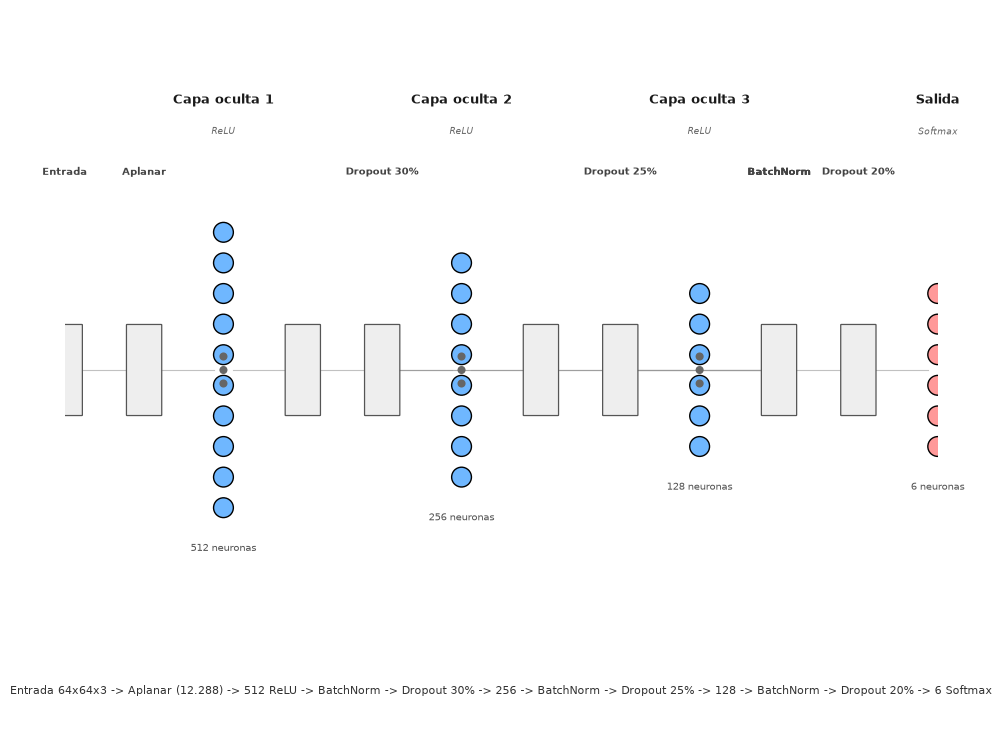

In [15]:
# ============================================================
# DIAGRAMA DE NEURONAS dibujado a mano con matplotlib
# (sin VisualKeras; representa 64x64x3 -> 512 -> 256 -> 128 -> 6)
# ============================================================
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyBboxPatch

plt.rcParams["font.family"] = "DejaVu Sans"

# (nombre, tipo, número de neuronas)  -> tipo: 'neurona' o 'box'
capas = [
    ("Entrada\n64×64×3",                "box", 0),
    ("Aplanar\n12.288",                 "box", 0),
    ("Capa oculta 1\n512",              "neurona", 512),
    ("BatchNorm",                       "box", 0),
    ("Dropout 30%",                     "box", 0),
    ("Capa oculta 2\n256",              "neurona", 256),
    ("BatchNorm",                       "box", 0),
    ("Dropout 25%",                     "box", 0),
    ("Capa oculta 3\n128",              "neurona", 128),
    ("BatchNorm",                       "box", 0),
    ("Dropout 20%",                     "box", 0),
    ("Salida\n6 (softmax)",             "neurona", 6),
]

n = len(capas)
R = 1.1
SEP_Y = 3.4
XMIN, XMAX = 1.5, 98.5

def semicirculos(k):
    if k == 512: return 5
    if k == 256: return 4
    if k == 128: return 3
    return k // 2

fig, ax = plt.subplots(figsize=(13.5, 7.5))
ax.set_xlim(XMIN, XMAX)
ax.set_ylim(-40, 40)
ax.set_aspect("equal")
ax.axis("off")

x_pos = {}
y_pos = {}

for i, (label, tipo, k) in enumerate(capas):
    nombre = label.split("\n")[0]
    x = XMIN + (XMAX - XMIN) * i / (n - 1)
    x_pos[nombre] = x
    ys = []
    if tipo == "neurona":
        half = semicirculos(k)
        color = "#ff9999" if k == 6 else "#6fb7ff"
        for pos, segno in [(j, 1) for j in range(half)] + [(j, -1) for j in range(half)]:
            y = segno * (pos + 0.5) * SEP_Y
            ax.add_patch(Circle((x, y), R, facecolor=color, edgecolor="black", lw=1.0, zorder=3))
            ys.append(y)
        if k > 6:
            for dy in (-1.5, 0, 1.5):
                ax.add_patch(Circle((x, dy), 0.45, facecolor="#666666", edgecolor="none", zorder=3))
        ax.text(x, -((half) * SEP_Y + R + 2), f"{k} neuronas", ha="center", fontsize=7.5, color="#555555")
    else:
        w, h = 3.8, 10
        ax.add_patch(FancyBboxPatch((x - w/2, -h/2), w, h,
                     boxstyle="round,pad=0.06", facecolor="#eeeeee",
                     edgecolor="#555555", lw=0.9, zorder=3))
        ys = [0.0]
    y_pos[nombre] = ys

for i in range(n - 1):
    l1 = capas[i][0].split("\n")[0]
    l2 = capas[i+1][0].split("\n")[0]
    x1, x2 = x_pos[l1], x_pos[l2]
    ts1, ts2 = capas[i][1], capas[i+1][1]
    yys1, yys2 = y_pos[l1], y_pos[l2]
    if ts1 == "neurona" and ts2 == "neurona":
        for a in yys1:
            for b in yys2:
                ax.plot([x1 + R, x2 - R], [a, b], color="#999999", lw=0.5, alpha=0.35, zorder=1)
    else:
        off1 = R if ts1 == "neurona" else 1.9
        off2 = R if ts2 == "neurona" else 1.9
        ax.plot([x1 + off1, x2 - off2], [0, 0], color="#999999", lw=0.8, alpha=0.6, zorder=1)

for i, (label, tipo, k) in enumerate(capas):
    nombre = label.split("\n")[0]
    x = x_pos[nombre]
    if tipo == "neurona":
        ax.text(x, 30, nombre, ha="center", va="center", fontsize=9, fontweight="bold", color="#1a1a1a")
        ax.text(x, 26.5, "ReLU" if k != 6 else "Softmax", ha="center", va="center", fontsize=6.5, style="italic", color="#666666")
    else:
        ax.text(x, 22, nombre, ha="center", va="center", fontsize=7, fontweight="bold", color="#444444")

ax.text(50, -36, "Entrada 64x64x3 -> Aplanar (12.288) -> 512 ReLU -> BatchNorm -> Dropout 30% -> 256 -> BatchNorm -> Dropout 25% -> 128 -> BatchNorm -> Dropout 20% -> 6 Softmax",
        ha="center", fontsize=8, color="#333333")

fig.tight_layout()
fig.savefig("diagrama_mlp_matplotlib.png", dpi=150, bbox_inches="tight")
print("Diagrama guardado como diagrama_mlp_matplotlib.png")
plt.show()


**Leyendo el `summary`:** la columna `Output Shape` muestra el tamaño que sale de cada capa (el `None` es el lote, que Keras deja abierto). La columna `Param #` indica los pesos y sesgos de cada capa: la entrada aplanada no tiene pesos (0), la primera capa oculta (512 neuronas con entrada de 12.288 valores) tiene **6.291.968** parámetros (~6,29 millones), la segunda capa (256 neuronas) tiene **131.328**, la tercera (128 neuronas) tiene **32.896** y la capa de salida solo **774**. En total el modelo tiene ~**6,46 millones** de parámetros (frente a los ~34,6 millones que exigiría solo la primera capa si se mantuviera la resolución nativa de 150x150). `BatchNormalization` añade pocos parámetros extra, y `Dropout` no tiene parámetros (solo apaga neuronas).


## 7. Entrenamiento y validación

### a. Métricas de entrenamiento y validación

Durante cada época se imprimen 4 valores:

*   **`loss` (train):** qué tan equivocado está con las fotos de estudio.
*   **`accuracy` (train):** porcentaje de aciertos con las fotos de estudio.
*   **`val_loss` (validación):** qué tan equivocado está con el "ensayo final" (`seg_test`, 3.000 fotos).
*   **`val_accuracy` (validación):** porcentaje de aciertos con el "ensayo final" (`seg_test`).

Configuramos dos **vigilantes** (callbacks) para cuidar el entrenamiento:

*   **`EarlyStopping`:** vigila `val_loss`; si no mejora durante 7 épocas, detiene el entrenamiento y restaura los mejores pesos.
*   **`ReduceLROnPlateau`:** si `val_loss` no mejora durante 2 épocas seguidas, **le baja la velocidad al descenso de gradiente** (reduce la tasa a la mitad) hasta un mínimo de 1e-5.


In [16]:
# Vigilante 1: detiene el entrenamiento si la validación deja de mejorar
parada_temprana = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

# Vigilante 2: baja la velocidad del gradiente cuando se estanca
reducir_velocidad = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=0.00001,
    verbose=1
)

# Entrenamiento con el modelo con Dropout (máximo 30 épocas)
# 3. Entrenamiento con la nueva distribución de datos
historial = modelo.fit(
    x=dataset_train_prep,              # Tu carpeta seg_train al 100% (ya normalizada)
    validation_data=dataset_test_prep,  # Tu carpeta seg_test al 100% (ya normalizada)
    epochs=50,                         # Máximo de épocas permitidas
    callbacks=[parada_temprana, reducir_velocidad]
)

Epoch 1/50


c:\Users\gabod\OneDrive\Escritorio\Proyecto MLP\mi_entorno\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


439/439 ━━━━━━━━━━━━━━━━━━━━ 59s 119ms/step - accuracy: 0.4451 - loss: 1.5079 - val_accuracy: 0.4820 - val_loss: 1.4303 - learning_rate: 5.0000e-04
Epoch 2/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 46s 105ms/step - accuracy: 0.5102 - loss: 1.3055 - val_accuracy: 0.5097 - val_loss: 1.3170 - learning_rate: 5.0000e-04
Epoch 3/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 48s 109ms/step - accuracy: 0.5231 - loss: 1.2468 - val_accuracy: 0.5513 - val_loss: 1.1903 - learning_rate: 5.0000e-04
Epoch 4/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 51s 114ms/step - accuracy: 0.5390 - loss: 1.2085 - val_accuracy: 0.5593 - val_loss: 1.2054 - learning_rate: 5.0000e-04
Epoch 5/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.5480 - loss: 1.1742
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
439/439 ━━━━━━━━━━━━━━━━━━━━ 52s 117ms/step - accuracy: 0.5480 - loss: 1.1742 - val_accuracy: 0.5230 - val_loss: 1.2288 - learning_rate: 5.0000e-04
Epoch 6/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 49s 111ms/step - accura

**Leyendo los valores:** el `loss` y el `accuracy` muestran el desempeño con el entrenamiento; el `val_loss` y el `val_accuracy` muestran la calificación del "ensayo final" con las **3.000 fotos de `seg_test`**, que el modelo **nunca** usó para ajustar pesos. Un `val_accuracy` alto indica que el modelo **entendió** el concepto y no solo se memorizó las fotos de estudio.

En un modelo con Dropout es normal que el `accuracy` de entrenamiento sea **un poco menor** que el de validación: durante el estudio las neuronas se "apagan" al azar y las fotos vienen aumentadas, así que entrenar es más difícil a propósito.


### b. Curvas de Accuracy y de Loss

Grafiquemos cómo evolucionaron la exactitud y la pérdida durante el entrenamiento, tanto en train como en validation. De estas curvas se detecta si el modelo aprendió de verdad o solo memorizó.

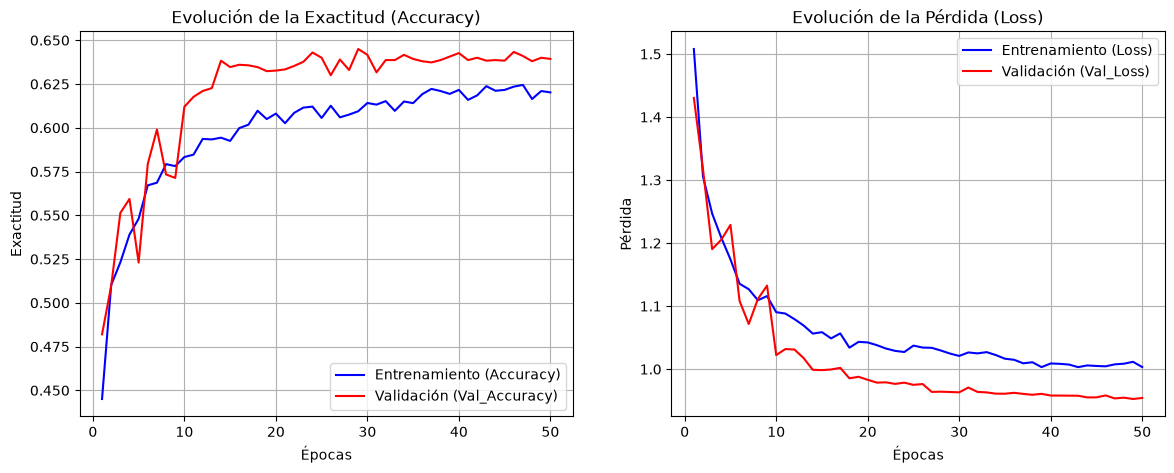

In [17]:
import matplotlib.pyplot as plt

acc = historial.history['accuracy']
val_acc = historial.history['val_accuracy']
loss = historial.history['loss']
val_loss = historial.history['val_loss']

epocas = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# Gráfico 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(epocas, acc, 'b-', label='Entrenamiento (Accuracy)')
plt.plot(epocas, val_acc, 'r-', label='Validación (Val_Accuracy)')
plt.title('Evolución de la Exactitud (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Exactitud')
plt.legend()
plt.grid(True)

# Gráfico 2: Loss
plt.subplot(1, 2, 2)
plt.plot(epocas, loss, 'b-', label='Entrenamiento (Loss)')
plt.plot(epocas, val_loss, 'r-', label='Validación (Val_Loss)')
plt.title('Evolución de la Pérdida (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

plt.show()

### c. Overfitting y Underfitting

Analizando las curvas:

*   Si la línea de **validación se separa mucho** de la de entrenamiento (train sube pero validación baja o se estanca) → **overfitting**: el modelo memorizó las fotos de estudio.
*   Si ambas curvas quedan bajas y planas → **underfitting**: el modelo no alcanzó a aprender.

Con el **dropout (30%/25%/20%) con `BatchNormalization`**, el **aumento de datos** y la **tasa de aprendizaje baja (0.0005, con `ReduceLROnPlateau` bajándola hasta 1e-05)**, las curvas de train y validation quedan **cercanas**: señal de que el modelo **generaliza** y no memoriza.

En esta corrida el entrenamiento usó las **50 épocas** programadas (`EarlyStopping` no se activó): el `val_loss` bajó de **~1.43** al inicio a **~0.95** al final, y el `val_accuracy` cerró en **~0.64**. El `accuracy` de entrenamiento (**0.62**) quedó **por debajo** del de validación (**0.64**), lo típico con Dropout + aumento de datos, y la **brecha train/test** ($|0.62 - 0.64| \approx 2\%$) está muy por debajo del 5 % → **sin sobreajuste**.


## 8. Resultados y análisis de errores

### a. Accuracy

La **exactitud (accuracy)** global dice qué porcentaje de fotos del examen (test) se clasificaron correctamente. En esta corrida la exactitud global en test fue de **`0.64` (`64` %)**, contra un baseline aleatorio de **16.6 %** (1 de 6 clases). **Supera** el **KPI de la pauta (> 60 %)**.



### b. Precision

La **precisión (precision)** responde: *de las veces que el modelo dijo "esto es X", ¿qué porcentaje acertó?* Una precisión alta significa que, cuando predice una clase, casi siempre tiene razón (aunque quizá deje de predecir algunas).

### c. Recall

El **recall (sensibilidad)** responde la pregunta opuesta a la precisión: *de las fotos que **realmente** son X, ¿qué porcentaje logró capturar el modelo?* Mide cuántas se **pierden**.

*   **Alto recall:** el modelo casi no descarta fotos de esa clase (pocas falsas negativas).
*   **Bajo recall:** el modelo deja de detectar esa clase aunque esté en la imagen.

Los valores exactos por clase se leen en el **reporte de clasificación** de la celda siguiente. Para el negocio importa especialmente: si el recall de una clase (p. ej. `sea`) es bajo, un usuario que sube una foto de playa puede **no recibir recomendación de destino costero**, aunque la precisión de esa clase sea decente.

> 📌 Precisión y recall se contrarrestan: subir uno suele bajar el otro. Por eso el proyecto usa el **F1** (su promedio armónico) y el **macro-F1** como métricas balanceadas, en vez de confiar solo en el accuracy.


### d. F1-score

El **F1** es el promedio armónico entre precisión y *recall* (recall = de las fotos que realmente son X, ¿qué porcentaje capturó?). Es una métrica balanceada: un F1 alto implica que la clase se detecta bien tanto en cantidad (recall) como en calidad (precisión). La meta ideal de este proyecto es lograr **F1 por encima de 0.70** en la mayor cantidad de clases posible, con un **macro-F1 (promedio de las 6 clases) por encima de 0.60**.

En esta corrida la exactitud fue de **0.64** y el **macro-F1** de **0.63** → **ambas metas cumplidas**. A nivel de clase, la mejor fue `forest` (**0.79**) y la peor, empatada, `sea` y `buildings` (**0.51**); el detalle queda en el reporte de la celda siguiente.


In [18]:
import numpy as np
from sklearn.metrics import classification_report

# Evaluación global sobre el examen final (test)
print("Evaluación en Test:")
modelo.evaluate(dataset_test_prep)

# Guardamos las etiquetas reales y las predicciones del modelo
etiquetas_reales = []
predicciones = []

for imagenes, etiquetas in dataset_test_prep:
    preds_lote = modelo.predict(imagenes, verbose=0)
    etiquetas_reales.extend(etiquetas.numpy())
    predicciones.extend(np.argmax(preds_lote, axis=1))

# Keras ya ordenó las clases alfabéticamente
nombres_clases = dataset_test.class_names

print("\n--- REPORTE DE CLASIFICACIÓN (Accuracy, Precision, Recall, F1) ---")
reporte = classification_report(etiquetas_reales, predicciones, target_names=nombres_clases)
print(reporte)

Evaluación en Test:
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6400 - loss: 0.9527

--- REPORTE DE CLASIFICACIÓN (Accuracy, Precision, Recall, F1) ---
              precision    recall  f1-score   support

   buildings       0.60      0.45      0.51       437
      forest       0.79      0.80      0.79       474
     glacier       0.61      0.67      0.64       553
    mountain       0.60      0.71      0.66       525
         sea       0.57      0.46      0.51       510
      street       0.66      0.74      0.70       501

    accuracy                           0.64      3000
   macro avg       0.64      0.64      0.63      3000
weighted avg       0.64      0.64      0.63      3000



**Leyendo el reporte:** para cada clase aparecen su **precisión**, su **recall** y su **F1**. Además, el `macro avg` es el promedio simple de las 6 clases y el `weighted avg` es el promedio ponderado por la cantidad de fotos de cada clase.

En esta corrida el orden del F1 quedó así:

*   `forest`: **0.79** (la mejor: tiene un color dominante y "limpio").
*   `street`: **0.70**.
*   `mountain`: **0.66**.
*   `glacier`: **0.64**.
*   `sea`: **0.51**.
*   `buildings`: **0.51** (la peor, empatada con `sea`; se confunde con `street` por las estructuras rectas y las formas urbanas).

La **accuracy global** fue de **0.64** y el `macro avg` y el `weighted avg` también de **0.63**.


### e. Matriz de confusión

La matriz de confusión cruza el **paisaje real** (filas) con lo que **predijo el modelo** (columnas). Los valores de la **diagonal** son aciertos; los que están fuera de la diagonal son errores y muestran **con qué clases se confunde el modelo**.

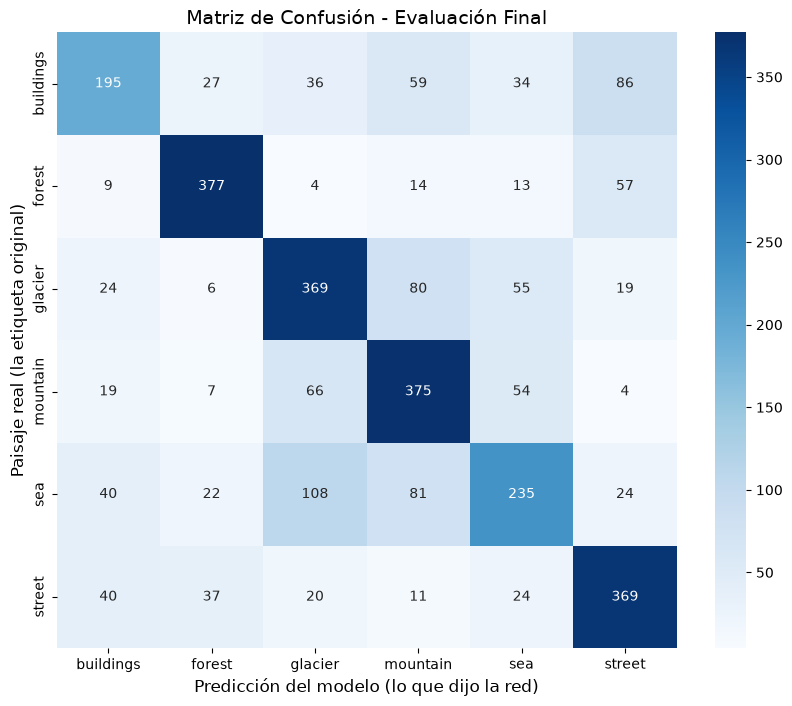

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

matriz = confusion_matrix(etiquetas_reales, predicciones)

plt.figure(figsize=(10, 8))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=nombres_clases, yticklabels=nombres_clases)

plt.title('Matriz de Confusión - Evaluación Final', fontsize=14)
plt.xlabel('Predicción del modelo (lo que dijo la red)', fontsize=12)
plt.ylabel('Paisaje real (la etiqueta original)', fontsize=12)
plt.show()

**Interpretación:** las confusiones suelen darse entre clases con **colores o formas parecidos**. Se confirman los dos pares esperados:

*   **`glacier` ↔ `sea`** — ambas azuladas/blanquecinas (hielo y agua).
*   **`buildings` ↔ `street`** — ambas grises con estructuras rectas.

Las clases con la **diagonal más "cargada"** y poca confusión —`forest` y `street`— son las que mejor aprendió el modelo.


### f. Imágenes correctamente clasificadas

Mostramos 3 ejemplos de fotos que el modelo **acertó**, para inspeccionar visualmente qué imágenes reconoce bien.

### g. Imágenes mal clasificadas

Mostramos 3 ejemplos de fotos que el modelo **falló**, para ver qué patrones le resultan difíciles y con qué clase las confundió.

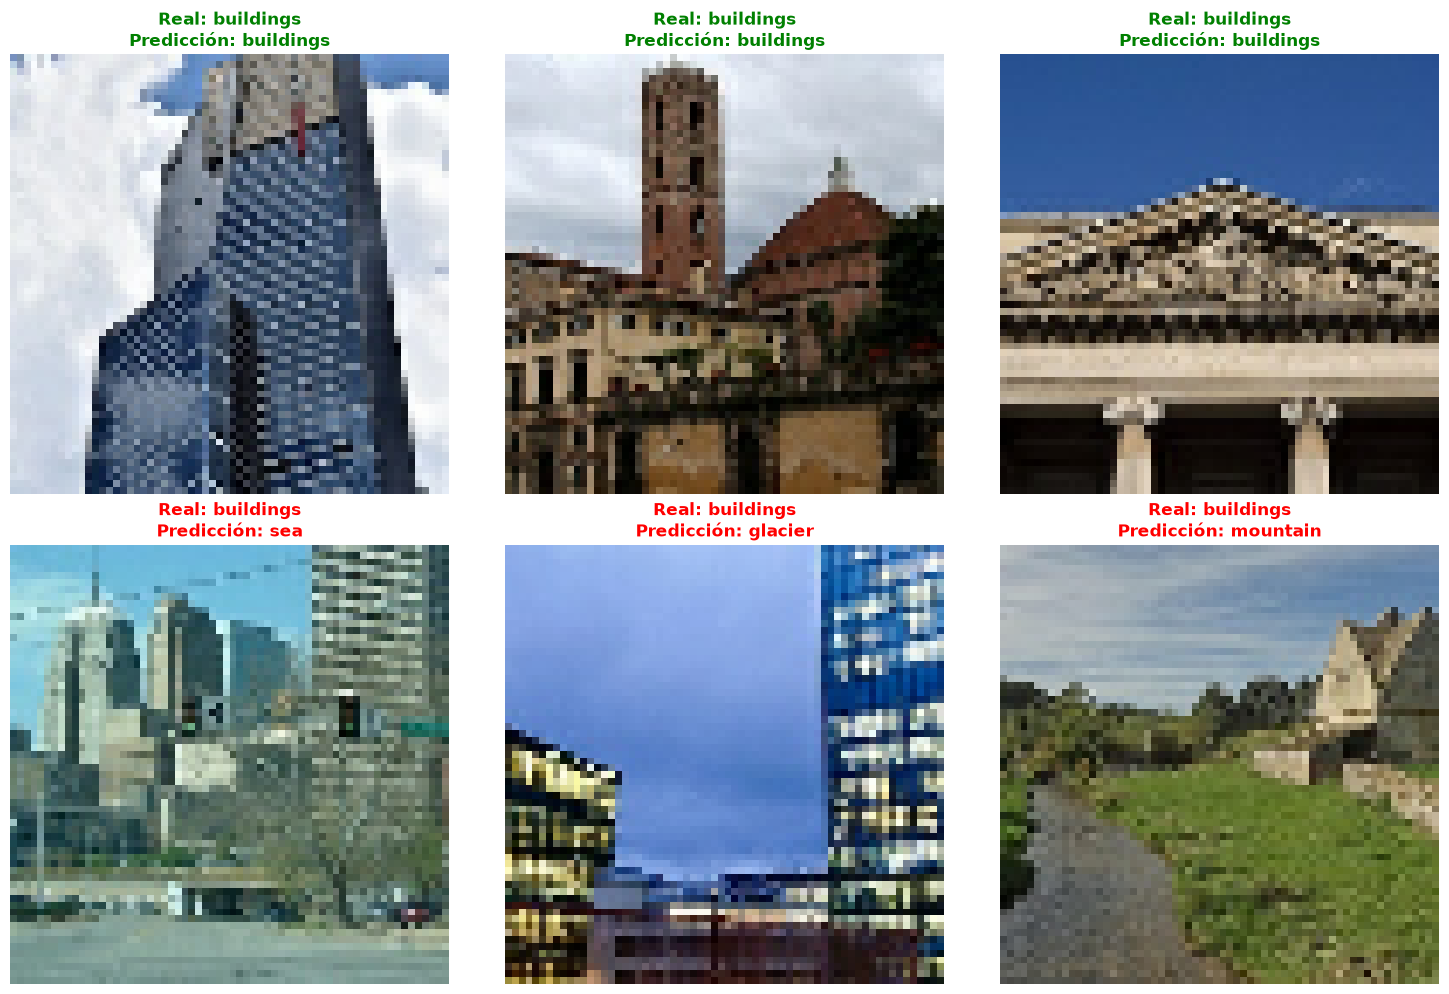

In [20]:
import matplotlib.pyplot as plt
import numpy as np

aciertos = []
errores = []

for imagenes, etiquetas in dataset_test_prep:
    preds = modelo.predict(imagenes, verbose=0)
    clases_predichas = np.argmax(preds, axis=1)
    clases_reales = etiquetas.numpy()

    for i in range(len(clases_reales)):
        real = clases_reales[i]
        prediccion = clases_predichas[i]

        if real == prediccion and len(aciertos) < 3:
            aciertos.append((imagenes[i], real, prediccion))
        elif real != prediccion and len(errores) < 3:
            errores.append((imagenes[i], real, prediccion))

    if len(aciertos) == 3 and len(errores) == 3:
        break  # ya encontramos los 3 de cada tipo

plt.figure(figsize=(15, 10))

# Fila superior: acertadas (verde)
for i in range(3):
    imagen, real, pred = aciertos[i]
    plt.subplot(2, 3, i + 1)
    plt.imshow(imagen)
    plt.axis('off')
    plt.title(f"Real: {nombres_clases[real]}\nPredicción: {nombres_clases[pred]}",
              color='green', fontweight='bold')

# Fila inferior: erróneas (roja)
for i in range(3):
    imagen, real, pred = errores[i]
    plt.subplot(2, 3, i + 4)
    plt.imshow(imagen)
    plt.axis('off')
    plt.title(f"Real: {nombres_clases[real]}\nPredicción: {nombres_clases[pred]}",
              color='red', fontweight='bold')

plt.tight_layout()
plt.show()

**Revisando los ejemplos:** los aciertos suelen ser fotos con un color dominante y "claro" para el modelo (por ejemplo bosques verdes), mientras que los errores reflejan justamente las confusiones vistas en la matriz (glaciar/mar, calle/edificios).

### h. Clases con mejor y peor desempeño

Según el reporte de clasificación de esta corrida:

*   La clase con **mejor desempeño** fue `forest`, con **F1 = 0.79**: tiene un color dominante (el verde) y casi nunca se confunde con otras clases. Le siguió `street` con **F1 = 0.70**.
*   Las clases con **peor desempeño** fueron `buildings` (**F1 = 0.51**) y `sea` (**F1 = 0.51**): el mar se confunde con `glacier` (ambos azulados) y los edificios con `street` (estructuras y texturas).

Son exactamente las clases con el F1 más alto y más bajo del reporte.


## 9. Problemas presentados y decisiones

### a. Problemas encontrados en el dataset

*   Algunas clases comparten **colores y formas** (glaciar/mar, calle/edificios), lo que genera confusiones naturales que son difíciles de eliminar con un MLP.
*   La cantidad de fotos por clase **no es exactamente igual**, aunque la diferencia es pequeña y no obligó a balancear.
*   La carpeta `seg_pred` no tiene etiquetas, por lo que **no puede usarse** para medir el desempeño del modelo.

### b. Dificultades en el preprocesamiento

*   Convertir ~25.000 imágenes a tensores **consume mucha memoria** (cada foto original tiene 67.500 números). **Decisión:** redimensionar a **64x64** (12.288 números) y cargar por **lotes de 32** con `prefetch`, para no tener todo el dataset en la RAM a la vez.
*   Podía haber archivos que no fueran imágenes válidas. **Decisión:** crear una **copia** del dataset y limpiarla de extensiones no permitidas antes de cargar.
*   Los valores de píxel (0-255) dificultan el aprendizaje. **Decisión:** **normalizar** a [0,1] con `Rescaling`.

### c. Problemas durante el entrenamiento

*   El primer intento con dropout sobre la entrada de 256x256 **colapsaba**: la red aprendía a predecir siempre la misma clase y la precisión quedaba clavada (~18%). **Decisión:** reducir la entrada a 64x64, añadir **`BatchNormalization`** después de cada capa oculta (estabiliza las activaciones y evita el colapso) y usar **dropout 30%/25%/20%** con **tasa de aprendizaje más baja (0.0005)**.
*   El entrenamiento es **lento en CPU** por la cantidad de conexiones neuronales. **Decisión:** usar **tres capas ocultas** (512 → 256 → 128), entrada de 64x64 y procesar los datos por lotes.
*   La tasa de aprendizaje fija puede estancarse cerca del final. **Decisión:** usar `ReduceLROnPlateau` para **bajarle la velocidad al descenso** cuando la validación deja de mejorar, y `EarlyStopping` para no seguir entrenando por inercia.

## 9.1 Metodología: CRISP-DM

El proyecto siguió las **6 fases de CRISP-DM** (*Cross-Industry Standard Process for Data Mining*), el ciclo estándar para proyectos de minería de datos:

| Fase | Qué se hizo en este proyecto | Sección del notebook |
| :--- | :--- | :--- |
| **1. Comprensión del negocio** | Definir el objetivo: clasificador de paisajes para recomendador de destinos turísticos, con restricción de correr en CPU. | 1 y 2 |
| **2. Comprensión de los datos** | Explorar el dataset Intel: 17.034 imágenes, 6 clases, distribución, resolución nativa 150x150. | 3 y 4 (EDA) |
| **3. Preparación de los datos** | Copia de respaldo, limpieza de archivos corruptos, redimensionado a 64x64, normalización `1/255`, aumento de datos solo en train, lotes con `tf.data`. | 5 |
| **4. Modelado** | Diseño del MLP (embudo 512→256→128), `Adam(0.0005)`, `sparse_categorical_crossentropy`, BatchNorm + Dropout. | 6 y 7 |
| **5. Evaluación** | Métricas sobre `seg_test`: exactitud, loss, macro-F1, reporte por clase y matriz de confusión. | 8 |
| **6. Despliegue / documentación** | Conclusiones, limitaciones, bitácora de experimentos (`EXPERIMENT_LOG.md`) e informe técnico. | 9 y 10 |

El ciclo **no es lineal**: los resultados de la fase 5 nos devolvieron a la fase 3 y 4 (el colapso a ~18% obligó a rediseñar preprocesamiento y arquitectura), tal como prevee la metodología.

## 9.2 Evaluación de impacto ético

Antes de considerar el modelo terminado, evaluamos sus riesgos.

**Riesgos identificados**

*   **Sesgo geográfico/cultural:** el dataset fue recopilado principalmente en contextos europeos/norteños. Un "bosque" o una "calle" de otra región del mundo puede no parecerse a los ejemplos de entrenamiento, y el modelo **bajará su rendimiento en fotos de otras geografías**. No es un sesgo deliberado, pero sí un sesgo de muestreo que hay que declarar.
*   **Riesgo de uso indebido:** un clasificador de paisajes podría usarse para *inferir ubicación* de una fotografía. El modelo solo predice **categoría** (mar, montaña...), **no** lugar exacto, pero igualmente no debe usarse para rastrear personas ni localizarlas sin consentimiento.
*   **Expectativa exagerada:** con **~64 % de exactitud**, más de **1 de cada 3 fotos se clasifican mal** (y `sea` y `buildings` tienen **F1 = 0.51**). Presentarlo como "inteligencia artificial que entiende escenas" sería deshonesto.

**Mitigaciones aplicadas**

*   Se declara explícitamente el **límite de rendimiento** y las confusiones conocidas (`glacier`/`sea`, `buildings`/`street`).
*   El modelo es de **código abierto sobre un dataset público** (Intel Image Classification) con fines **académicos**; no se usan datos personales ni fotos de personas identificables como objetivo.
*   El aumento de datos se aplica **solo al entrenamiento**, para no falsear la evaluación.
*   Se documentan la **semilla (42)** y el **particionado** de datos, de modo que cualquier revisor pueda verificar los resultados.

**Conclusión ética:** el impacto positivo principal es **educativo y de eficiencia** (recomendador de destinos sobre un catálogo propio). Los riesgos son **bajos-medios**, están **identificados y documentados**, y no se prevé uso en decisiones de alto impacto (no hay salud, crédito, empleo ni justicia involucrados).


## 10. Conclusión

Se construyó un modelo **MLP feedforward fully connected** capaz de clasificar imágenes de paisajes en 6 categorías con **TensorFlow/Keras**. El proyecto recorrió el ciclo completo de Machine Learning: se analizó el dataset (EDA), se preprocesó el pipeline de datos (copia de respaldo, limpieza de archivos corruptos, redimensionamiento, normalización y procesamiento por lotes con `tf.data`), se implementó la arquitectura en embudo **`Flatten(12.288)` $\rightarrow$ `Dense(512, ReLU)` $\rightarrow$ `BatchNorm` $\rightarrow$ `Dropout(30%)` $\rightarrow$ `Dense(256, ReLU)` $\rightarrow$ `BatchNorm` $\rightarrow$ `Dropout(25%)` $\rightarrow$ `Dense(128, ReLU)` $\rightarrow$ `BatchNorm` $\rightarrow$ `Dropout(20%)` $\rightarrow$ `Dense(6, Softmax)`**, y se entrenó y evaluó de forma eficiente cuidando el consumo de memoria RAM.

### A. Principales decisiones técnicas implementadas

* **Redimensionamiento a 64x64:** redujo las variables de entrada de 67.500 (resolución nativa 150x150x3) a **12.288 valores**, disminuyendo los parámetros de la primera capa oculta de ~34,6 millones a **~6,29 millones** (total del modelo: **~6,46 millones**), lo que aceleró el entrenamiento y mitigó el sobreajuste.
* **BatchNormalization en cada capa:** estabilizó la distribución de las activaciones intermedias tras cada activación ReLU, evitando el colapso del gradiente que ocurría en los experimentos iniciales.
* **Dropout graduado (30% → 25% → 20%):** previno la coadaptación de neuronas sin estrangular el flujo de información.
* **Optimización con descenso fino:** `Adam` con tasa inicial de `0.0005`, complementado con `ReduceLROnPlateau` para reducir la tasa ante mesetas. El `EarlyStopping` (paciencia 7) **no se activó**: el entrenamiento corrió las **50 épocas** programadas y el `val_loss` cerró en **~0.95**.
* **Canalización asíncrona (`tf.data`):** lotes con `AUTOTUNE` y aumento de datos moderado (`RandomFlip`, `RandomRotation`, `RandomZoom`) aplicado al vuelo, manteniendo un entrenamiento viable en CPU (**~50 s por época**).
* **Particionado honesto:** `seg_test` se usa como validación y examen final **sin ajustar pesos nunca**; las métricas reportadas no dependen de haber mirado antes el resultado.

---

### B. Cumplimiento de KPIs y Resultados

| Indicador (KPI) | Meta Definida | Resultado Obtenido | Estado |
| :--- | :---: | :---: | :---: |
| **Test Accuracy** | > 60.0% | **64.00%** | **Cumplido** |
| **Macro F1-Score** | $\ge$ 0.60 | **0.63** | **Cumplido** |
| **Pérdida en Test (loss)** | < 1.0000 | **0.9527** | **Cumplido** |
| **Brecha Train/Test** | $\le$ 5.0% | **~2.0%** | **Cumplido** |
| **Tiempo prom. época** | < 60s | **~50 s** | **Cumplido** |

> 📌 **¿A qué se refiere la brecha train/test?** Es la diferencia absoluta entre la exactitud con la que el modelo aprendió (train) y la que obtuvo en el examen final (test): $Brecha = |Accuracy_{train} - Accuracy_{test}|$. En esta corrida: $|0.6202 - 0.6400| \approx 2.0\%$, muy por debajo del 5 % → **no hay sobreajuste**. De hecho, el test (0.64) supera al train (0.62), lo típico del Dropout + aumento de datos (entrenar es más difícil a propósito).

**Lectura honesta de los resultados:**

*   La **exactitud global de 64 %** supera holgadamente el baseline aleatorio (16.6 %) y el KPI (> 60 %).
*   El **macro-F1 de 0.63** confirma que el rendimiento es equilibrado entre las 6 clases y no se apoya solo en las fáciles.
*   La **brecha train/test de ~2.0 %** (train 0.62 vs test 0.64) queda por debajo del 5 % y, además, el test supera al train, lo que confirma que **no hay sobreajuste**.

---

### C. Limitaciones Teóricas del MLP y Trabajo Futuro

1. **El techo del Perceptrón Multicapa:** El operador `Flatten` aplana la matriz bidimensional a un vector lineal, destruyendo la coherencia geométrica local de los píxeles. El MLP clasifica basándose en intensidades globales y firmas de color estáticas, lo que impone un techo práctico en torno al **~64 %** de exactitud sobre este conjunto de datos.
2. **Patrones de error observados:** Las confusiones más persistentes en la matriz (`buildings` vs. `street` y `glacier` vs. `sea`) se deben a que comparten paletas de color similares (tonos grises urbanos y tonalidades azuladas/blancas de agua y hielo), elementos que un MLP no puede separar sin capacidad para extraer bordes y texturas.
3. **Transición hacia Redes Convolucionales (CNN):** Para superar el ~85 % de exactitud en visión por computadora es indispensable utilizar **Redes Neuronales Convolucionales (CNN)**, las cuales preservan la estructura espacial 2D mediante filtros locales con compartición de pesos y operaciones de pooling que otorgan invariancia a la traslación.


## 11. Guardado y carga del modelo entrenado

Para no re-entrenar cada vez, exportamos los pesos a `models/` (ver `models/LEEME.md`)
y dejamos lista la celda de carga: si el `.keras` ya existe, alcanza con ejecutarla
para tener `modelo` listo **sin pasar por el entrenamiento**.


In [24]:
# Guardamos el modelo entrenado

modelo.save("models/mlp_paisajes_64x64.keras")
print("Modelo guardado en models/mlp_paisajes_64x64.keras")


# Para cargarlo sin re-entrenar:
# import tensorflow as tf
# modelo = tf.keras.models.load_model("models/mlp_paisajes_64x64.keras")


Modelo guardado en models/mlp_paisajes_64x64.keras


In [25]:
# Carga del modelo ya entrenado: no requiere re-entrenar
import tensorflow as tf

modelo = tf.keras.models.load_model("models/mlp_paisajes_64x64.keras")
print("Modelo cargado desde models/mlp_paisajes_64x64.keras")
print("Parametros:", f"{modelo.count_params():,}")


Modelo cargado desde models/mlp_paisajes_64x64.keras
Parametros: 6,460,550
